# 04 — Explore & Understand the Data

This notebook provides a thorough visual and statistical exploration of the
MAESTRO dataset and the pipeline outputs.  Run it after `03_verify_pipeline`
confirms the pipeline is working.

**Sections:**
1. Dataset statistics (duration, note count, split sizes)
2. Load and inspect one piece
3. Visualise the log-mel spectrogram
4. Visualise the piano roll labels (all 4 heads)
5. THE alignment check (mel vs frame roll)
6. Inspect a training batch
7. Augmentation before/after
8. Summary statistics over 20 random items

## Setup

In [33]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive


In [34]:

import os
from getpass import getpass

REPO_DIR = '/content/AMT_FYP'

TOKEN = getpass('GitHub token: ')

if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://{TOKEN}@github.com/Mobinmo83/AMT_FYP.git {REPO_DIR}")
    print(f"Cloned into {REPO_DIR} ✓")
else:
    print(f"Repo already exists at {REPO_DIR}")
    os.system(f"cd {REPO_DIR} && git pull")

GitHub token: ··········
Repo already exists at /content/AMT_FYP


In [35]:

import sys
sys.path.insert(0, '/content/AMT_FYP/piano_amt')

In [36]:
!pip install -q -r /content/AMT_FYP/piano_amt/requirements.txt

In [37]:
import sys, os, glob
from pathlib import Path

REPO_DIR     = '/content/FYP_AMT/piano_amt'
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
%matplotlib inline

from src.constants import *
from src.audio import load_audio, wav_to_log_mel, load_audio_as_log_mel
from src.midi import midi_path_to_rolls
from src.dataset import MAESTRODataset, load_from_cache, _cache_path
from src.dataloader import get_dataloader
from src.transforms import get_train_transform
from src.utils.viz import (
    plot_mel, plot_piano_roll, plot_mel_with_labels, plot_batch_sample
)

print("✓ Setup complete")

✓ Setup complete


## 1. Dataset statistics

Split sizes:
split
test          177
train         962
validation    137

Total duration: 198.7 hours
Duration range: 45.2s – 2624.7s
Mean duration : 560.5s


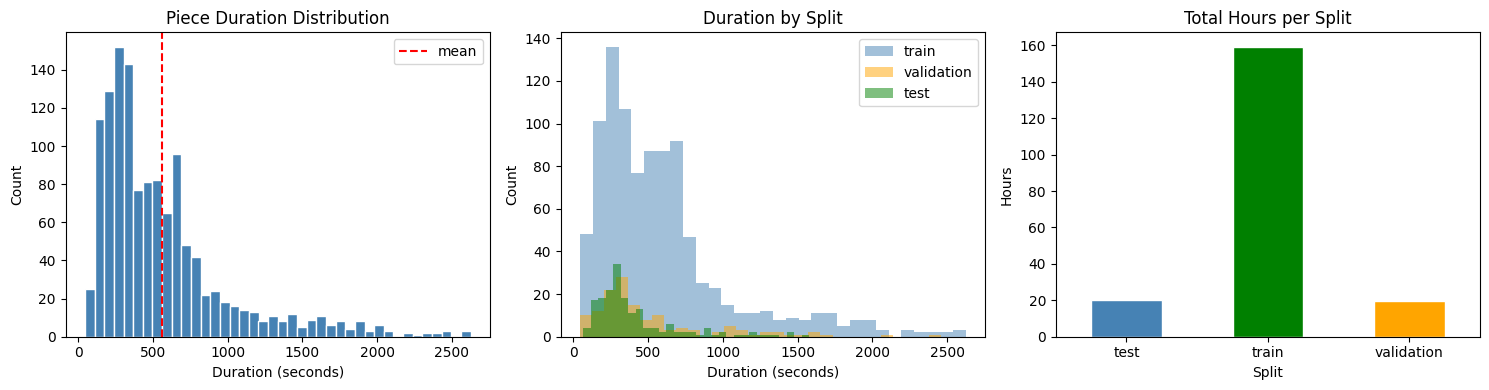

In [38]:
csv_files = sorted(glob.glob(f"{MAESTRO_ROOT}/*.csv"))
df = pd.read_csv(csv_files[0])

print("Split sizes:")
split_counts = df.groupby('split').size()
print(split_counts.to_string())

print(f"\nTotal duration: {df['duration'].sum()/3600:.1f} hours")
print(f"Duration range: {df['duration'].min():.1f}s – {df['duration'].max():.1f}s")
print(f"Mean duration : {df['duration'].mean():.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Duration histogram
axes[0].hist(df['duration'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Piece Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['duration'].mean(), color='red', linestyle='--', label='mean')
axes[0].legend()

# Duration by split
for split, color in zip(['train', 'validation', 'test'], ['steelblue', 'orange', 'green']):
    sub = df[df['split'] == split]
    axes[1].hist(sub['duration'], bins=30, alpha=0.5, label=split, color=color)
axes[1].set_title('Duration by Split')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Split sizes bar chart
split_hrs = df.groupby('split')['duration'].sum() / 3600
split_hrs.plot(kind='bar', ax=axes[2], color=['steelblue', 'green', 'orange'], edgecolor='white')
axes[2].set_title('Total Hours per Split')
axes[2].set_xlabel('Split')
axes[2].set_ylabel('Hours')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Load and inspect one piece

In [39]:
train_rows = df[df['split'] == 'train'].reset_index(drop=True)
row = train_rows.iloc[0]

audio_path = str(Path(MAESTRO_ROOT) / row['audio_filename'])
midi_path  = str(Path(MAESTRO_ROOT) / row['midi_filename'])

print(f"Piece     : {Path(audio_path).name}")
print(f"Duration  : {row['duration']:.1f} s")
print(f"Year      : {row.get('year', 'N/A')}")
print(f"Audio     : {audio_path}")
print(f"MIDI      : {midi_path}")

Piece     : MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav
Duration  : 698.7 s
Year      : 2018
Audio     : /content/drive/MyDrive/piano_amt/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav
MIDI      : /content/drive/MyDrive/piano_amt/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi


## 3. Visualise the log-mel spectrogram

log_mel.shape : (229, 313)
log_mel.min() : -12.8850
log_mel.max() : 7.8155
log_mel.mean(): -6.9044


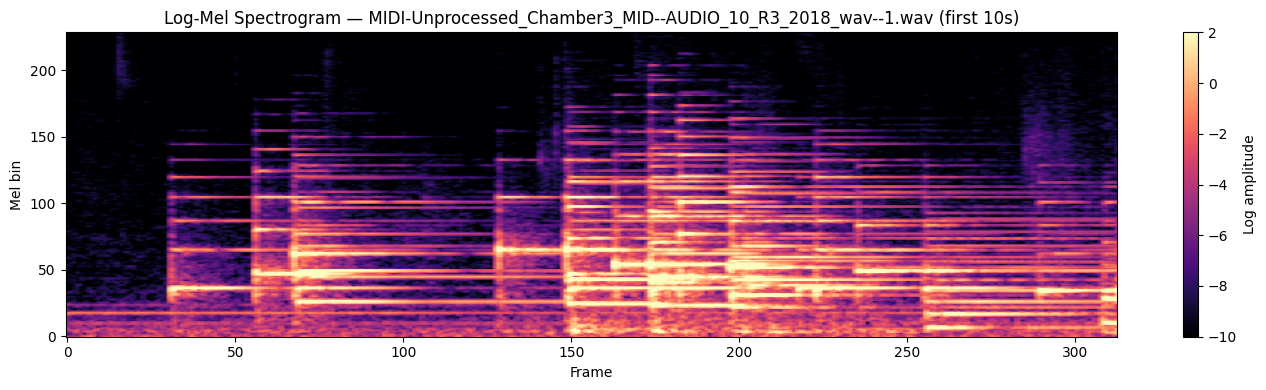

In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load a 10-second clip
CLIP_DURATION_S = 10.0
waveform, sr = load_audio(audio_path, target_sr=SAMPLE_RATE, mono=True)
clip_samples = int(CLIP_DURATION_S * SAMPLE_RATE)
waveform_clip = waveform[:, :clip_samples]

log_mel = wav_to_log_mel(waveform_clip, device=device)
print(f"log_mel.shape : {tuple(log_mel.shape)}")
print(f"log_mel.min() : {log_mel.min().item():.4f}")
print(f"log_mel.max() : {log_mel.max().item():.4f}")
print(f"log_mel.mean(): {log_mel.mean().item():.4f}")

plot_mel(
    log_mel,
    title=f"Log-Mel Spectrogram — {Path(audio_path).name} (first {CLIP_DURATION_S:.0f}s)",
    figsize=(14, 4),
)

## 4. Visualise the piano roll labels

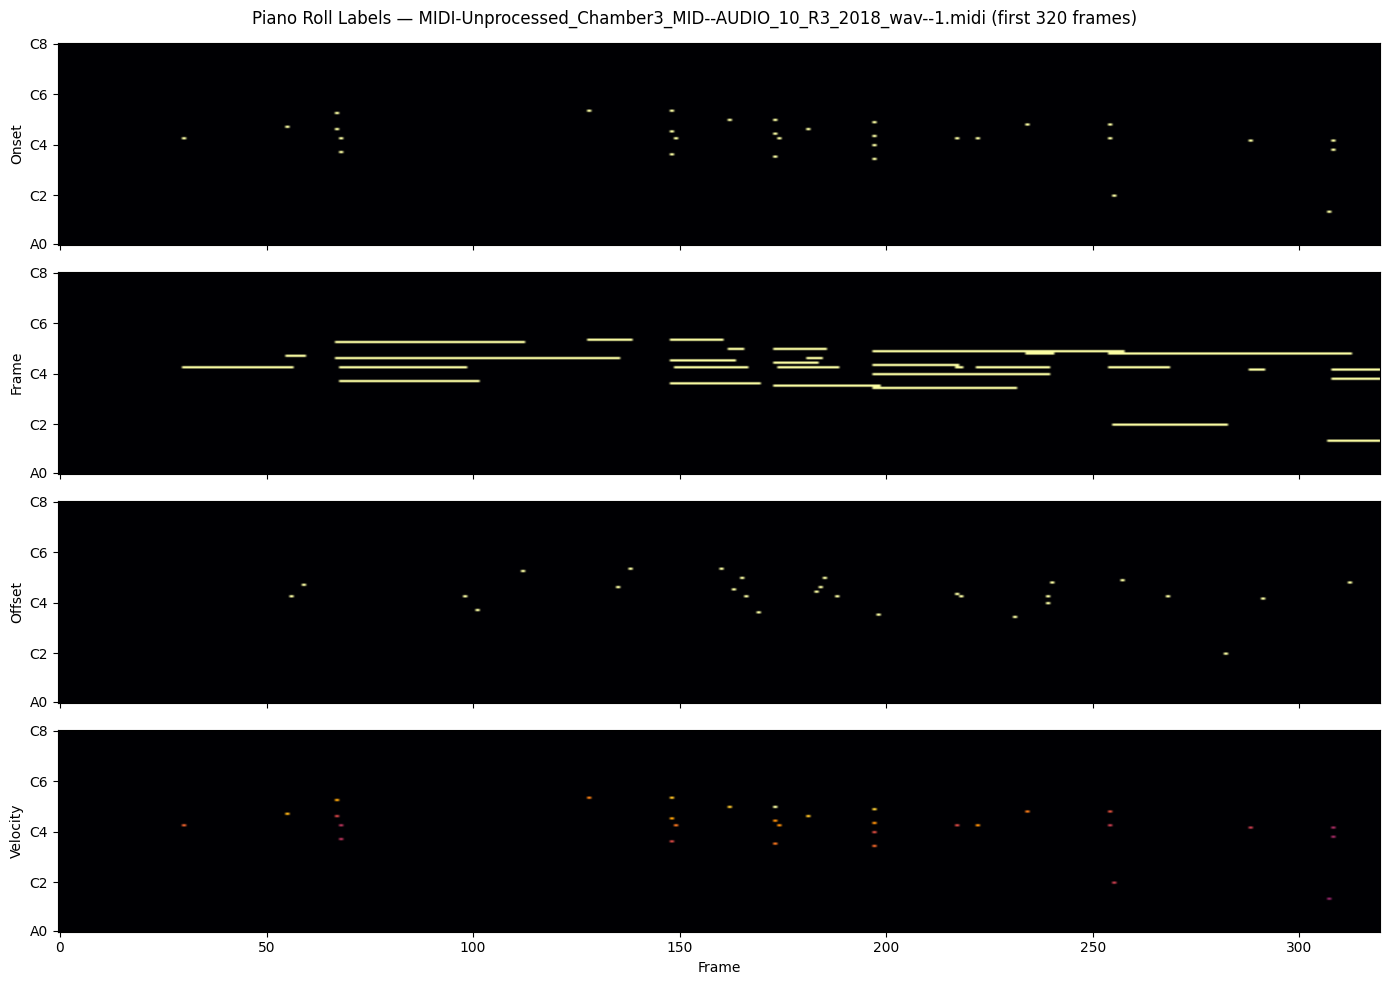

In [41]:
# Load full-length mel to get n_frames, then compute rolls
waveform_full, _ = load_audio(audio_path, target_sr=SAMPLE_RATE, mono=True)
log_mel_full = wav_to_log_mel(waveform_full, device=device)
n_frames_full = log_mel_full.shape[1]

onset, frame, offset, velocity = midi_path_to_rolls(
    midi_path, n_frames=n_frames_full, start_sec=0.0, duration_sec=None
)

# Show first 320 frames (~10 seconds)
N_SHOW = 320
plot_piano_roll(
    onset=onset[:N_SHOW],
    frame=frame[:N_SHOW],
    offset=offset[:N_SHOW],
    velocity=velocity[:N_SHOW],
    title=f"Piano Roll Labels — {Path(midi_path).name} (first {N_SHOW} frames)",
    figsize=(14, 10),
)

## 5. THE alignment check

**This is the most important visual check in the pipeline.**

Bright horizontal bands in the mel spectrogram (overtone series of active piano notes)
must line up **vertically** with active columns in the frame roll (active piano keys).

If they don't align → there is a bug in `fps`, `HOP_LENGTH`, or the time-shift
code in `midi_path_to_rolls`.

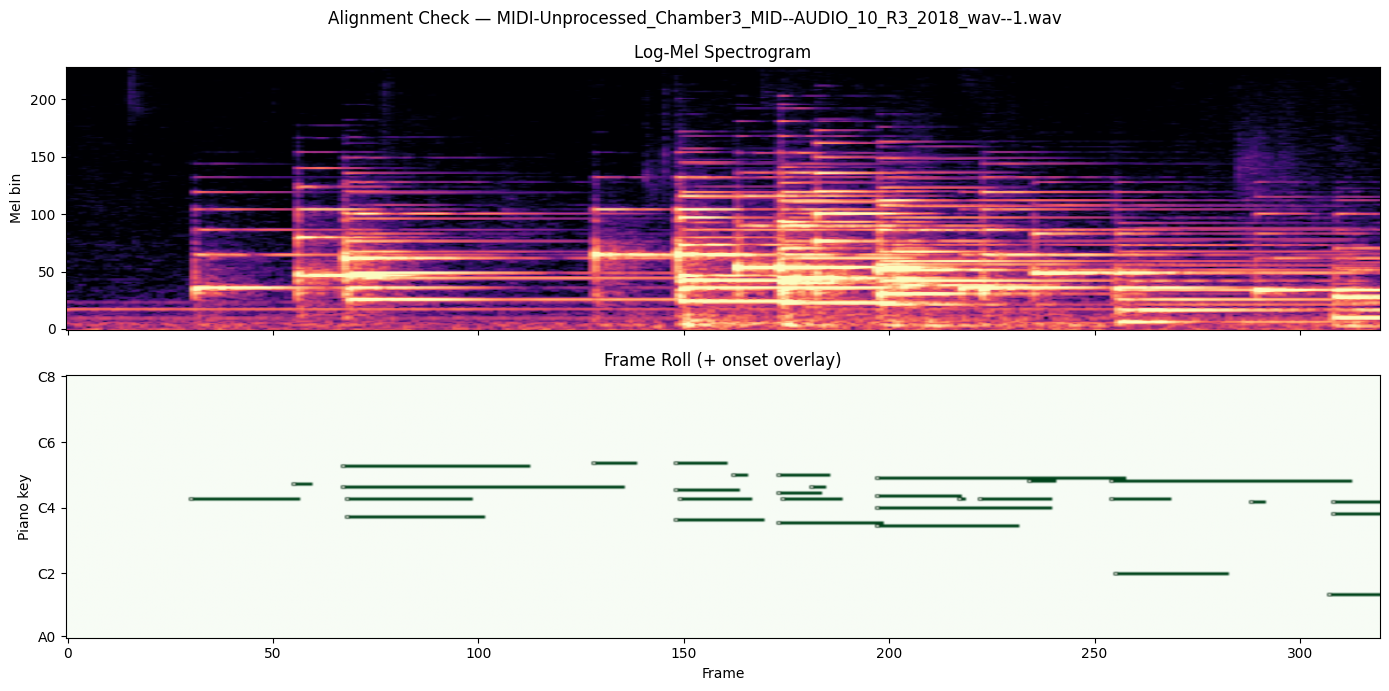

INTERPRETATION:
  ✓ Bright vertical bands in the mel should coincide with
    active columns (white) in the frame roll.
  ✗ If they are offset → fps or HOP_LENGTH mismatch bug.


In [42]:
plot_mel_with_labels(
    mel=log_mel_full,
    frame=frame,
    onset=onset,
    n_frames=320,
    figsize=(14, 7),
    title=f"Alignment Check — {Path(audio_path).name}",
)

print("INTERPRETATION:")
print("  ✓ Bright vertical bands in the mel should coincide with")
print("    active columns (white) in the frame roll.")
print("  ✗ If they are offset → fps or HOP_LENGTH mismatch bug.")

## 6. Inspect a training batch

Batch summary:
  mel         : (4, 229, 640)  dtype=torch.float32
  onset       : (4, 640, 88)  dtype=torch.float32
  frame       : (4, 640, 88)  dtype=torch.float32
  offset      : (4, 640, 88)  dtype=torch.float32
  velocity    : (4, 640, 88)  dtype=torch.float32
  audio_path  : ['/content/drive/MyDrive/piano_amt/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav', '/content/drive/MyDrive/piano_amt/maestro-v3.0.0/2006/MIDI-Unprocessed_19_R1_2006_01-07_ORIG_MID--AUDIO_19_R1_2006_04_Track04_wav.wav', '/content/drive/MyDrive/piano_amt/maestro-v3.0.0/2011/MIDI-Unprocessed_15_R1_2011_MID--AUDIO_R1-D6_09_Track09_wav.wav', '/content/drive/MyDrive/piano_amt/maestro-v3.0.0/2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MID--AUDIO_03_R2_2008_wav--2.wav']
audio_path : /content/drive/MyDrive/piano_amt/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav
mel.shape  : (229, 640)
onset.shape: (640, 88)
Active onset frames : 6
Active frame events : 

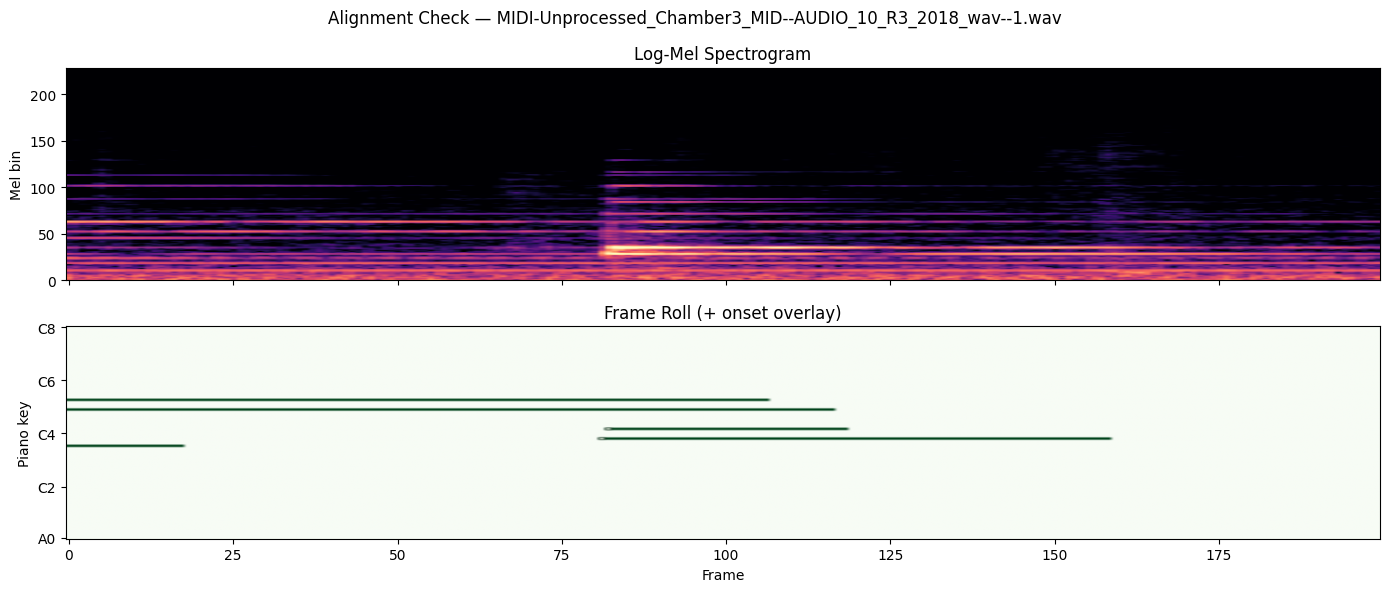

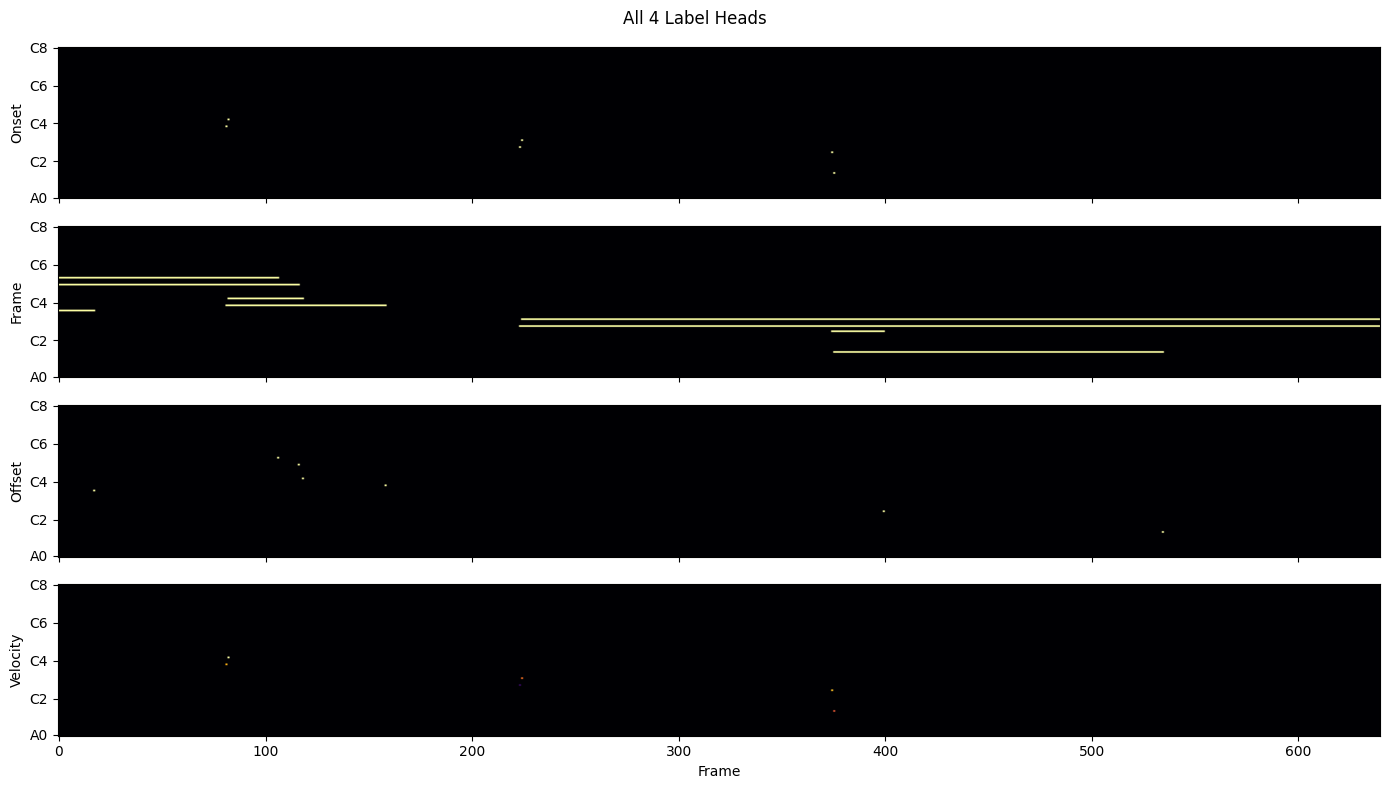

In [43]:
loader = get_dataloader(
    maestro_root=MAESTRO_ROOT,
    split='train',
    batch_size=4,
    num_workers=0,
    cache_dir=CACHE_DIR,
    max_files=10,
    use_augmentation=False,
    pin_memory=False,
)

batch = next(iter(loader))

print("Batch summary:")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:12s}: {tuple(v.shape)}  dtype={v.dtype}")
    else:
        print(f"  {k:12s}: {v}")

# Plot the first sample
plot_batch_sample(batch, idx=0, n_frames=200)

## 7. Augmentation before/after

Compare the mel spectrogram of the same item without and with augmentation
to understand the effect of pitch shift and masking.

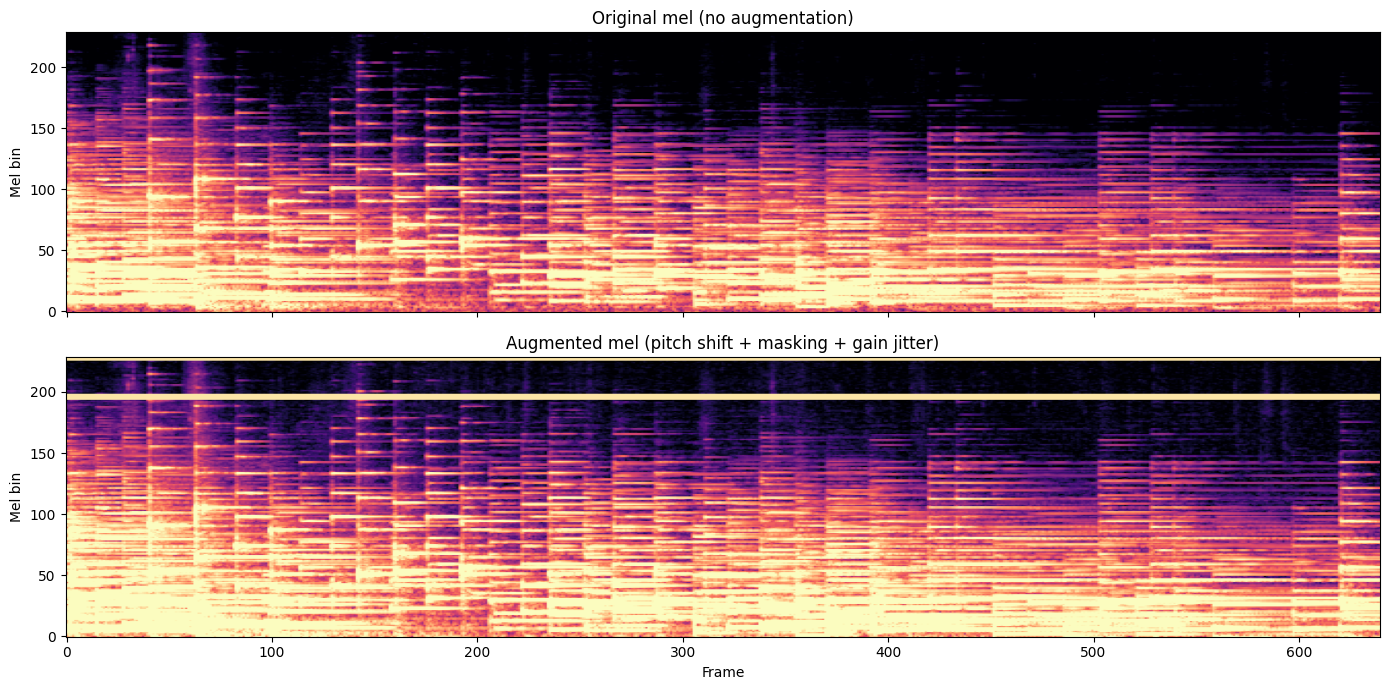

Mel difference (L2): 1397.1837


In [44]:
ds_raw = MAESTRODataset(
    maestro_root=MAESTRO_ROOT,
    split='train',
    cache_dir=CACHE_DIR,
    segment=True,
    max_files=5,
    seed=0,
)

item_raw = ds_raw[0]

# Apply augmentation manually
transform = get_train_transform(use_pitch_shift=True)

# Apply transform multiple times to get a visually striking result
import random
random.seed(99)  # fix seed so we get an augmented version
item_aug = transform({
    k: v.clone() if isinstance(v, torch.Tensor) else v
    for k, v in item_raw.items()
})

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

mel_raw = item_raw['mel'].numpy()
mel_aug = item_aug['mel'].numpy()

axes[0].imshow(mel_raw, aspect='auto', origin='lower', cmap='magma', vmin=-10, vmax=2)
axes[0].set_title('Original mel (no augmentation)')
axes[0].set_ylabel('Mel bin')

axes[1].imshow(mel_aug, aspect='auto', origin='lower', cmap='magma', vmin=-10, vmax=2)
axes[1].set_title('Augmented mel (pitch shift + masking + gain jitter)')
axes[1].set_ylabel('Mel bin')
axes[1].set_xlabel('Frame')

plt.tight_layout()
plt.show()

print(f"Mel difference (L2): {((mel_raw - mel_aug)**2).sum()**.5:.4f}")

## 8. Summary statistics

Over 20 random training items, compute:
- Mean active notes per frame
- Onset density (fraction of onset positions that are active)
- Velocity distribution

Summary Statistics (over 20 training items)
  Mean active notes/frame : 2.550 ± 0.574
  Onset density           : 0.003295 ± 0.002091
  Velocity mean (norm.)   : 0.5153
  Velocity std  (norm.)   : 0.1548
  Velocity range          : [0.0234, 0.9609]


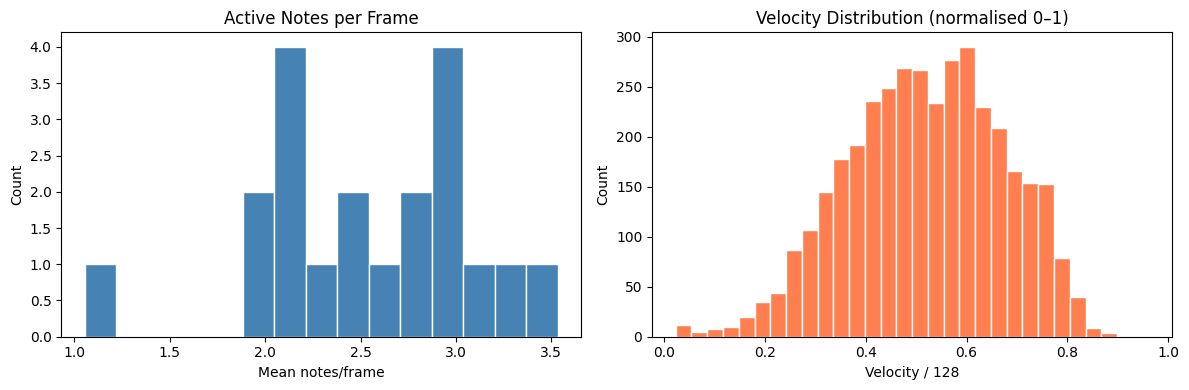

In [45]:
N_SAMPLES = 20
ds_stats = MAESTRODataset(
    maestro_root=MAESTRO_ROOT,
    split='train',
    cache_dir=CACHE_DIR,
    segment=True,
    max_files=N_SAMPLES,
)

all_active_notes = []
all_onset_density = []
all_velocities = []

for i in range(min(N_SAMPLES, len(ds_stats))):
    item = ds_stats[i]
    frame_roll    = item['frame']    # (640, 88)
    onset_roll    = item['onset']    # (640, 88)
    velocity_roll = item['velocity'] # (640, 88)

    # Mean active notes per frame
    notes_per_frame = frame_roll.sum(dim=1).mean().item()
    all_active_notes.append(notes_per_frame)

    # Onset density
    onset_density = onset_roll.mean().item()
    all_onset_density.append(onset_density)

    # Non-zero velocities
    vel_vals = velocity_roll[velocity_roll > 0].numpy()
    all_velocities.extend(vel_vals.tolist())

print("Summary Statistics (over {} training items)".format(len(all_active_notes)))
print(f"  Mean active notes/frame : {np.mean(all_active_notes):.3f} ± {np.std(all_active_notes):.3f}")
print(f"  Onset density           : {np.mean(all_onset_density):.6f} ± {np.std(all_onset_density):.6f}")
print(f"  Velocity mean (norm.)   : {np.mean(all_velocities):.4f}")
print(f"  Velocity std  (norm.)   : {np.std(all_velocities):.4f}")
print(f"  Velocity range          : [{min(all_velocities):.4f}, {max(all_velocities):.4f}]")

# Velocity histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_active_notes, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Active Notes per Frame')
axes[0].set_xlabel('Mean notes/frame')
axes[0].set_ylabel('Count')

axes[1].hist(all_velocities, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Velocity Distribution (normalised 0–1)')
axes[1].set_xlabel('Velocity / 128')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

1. Mean active notes/frame: 2.550 ± 0.574
On average 2.55 piano keys are active simultaneously in any given frame across your training pieces. The ±0.574 means some pieces are denser (chords, up to ~3 notes average) and some are sparser (melodic passages, ~2 notes average). This tells your model it needs to handle polyphony — it cannot assume only one note at a time. For the frame head, roughly 2.55 out of 88 keys are active per frame, which means about 97% of frame-key positions are 0. This is why pos_weight=5.0 in your loss is important — without it the model would just predict all zeros and get a deceptively low loss.

2. Onset density: 0.003295 ± 0.002091
Only 0.33% of all onset positions (frame × key) are active. This is the most extreme class imbalance in your pipeline. Out of 640 frames × 88 keys = 56,320 positions per segment, only ~186 are onset=1. Your pos_weight=5.0 compensates for this but you may want to consider increasing it to 8–10 for the onset head specifically, since this imbalance is more severe than the frame head.

3. Velocity mean: 0.5153, std: 0.1548
Mean normalised velocity is 0.515 which maps back to MIDI velocity 66 out of 127 — roughly mezzo-forte, the natural centre of piano dynamics. The std of 0.155 means velocities typically range from about 0.36 to 0.67 (roughly MIDI 46–86), covering the main dynamic range of classical piano. The full range [0.023, 0.961] shows occasional very soft and very loud notes exist but are rare. Your velocity head predicts values in [0,1] using masked MSE — this distribution confirms the targets are well-spread and learnable, not concentrated at one extreme.